Estimated percolation threshold phi_c ~ 0.150


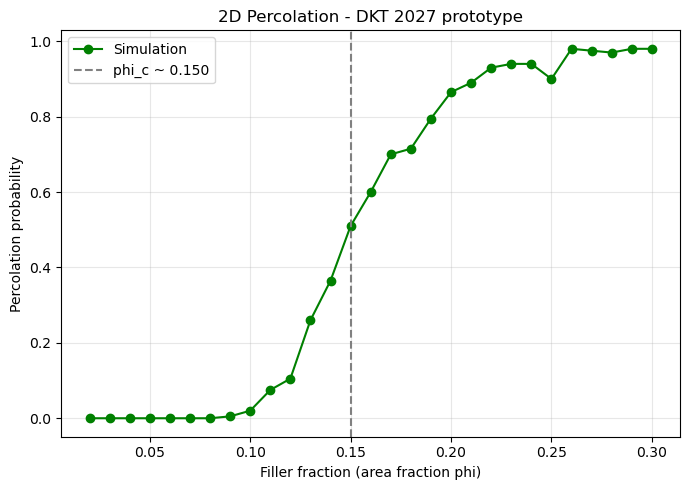

In [8]:
import numpy as np
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt

def single_trial(N, r, L=1.0, k=3.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pts = rng.random((N, 2)) * L
    tree = cKDTree(pts)
    pairs = tree.query_pairs(r=k * 2.0 * r)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(pairs)
    left  = set(np.where(pts[:, 0] <= r)[0])
    right = set(np.where(pts[:, 0] >= L - r)[0])
    if not left or not right:
        return False
    for comp in nx.connected_components(G):
        if comp & left and comp & right:
            return True
    return False

def percolation_probability(phi, r, L=1.0, k=3.0, trials=200, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = int(round(phi * L * L / (np.pi * r * r)))
    if N < 1:
        return 0.0
    return sum(single_trial(N, r, L, k, rng) for _ in range(trials)) / trials

rng = np.random.default_rng(42)
r, k, trials = 0.02, 3.0, 200
phi_values = np.linspace(0.02, 0.30, 29)
probs = np.array([percolation_probability(phi, r, k=k, trials=trials, rng=rng)
                  for phi in phi_values])

idx = np.argmax(probs >= 0.5)
phi_c = phi_values[idx] if probs[idx] >= 0.5 else float("nan")
print(f"Estimated percolation threshold phi_c ~ {phi_c:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(phi_values, probs, "o-", color="green", label="Simulation")
if not np.isnan(phi_c):
    plt.axvline(phi_c, ls="--", color="gray", label=f"phi_c ~ {phi_c:.3f}")
plt.xlabel("Filler fraction (area fraction phi)")
plt.ylabel("Percolation probability")
plt.title("2D Percolation - DKT 2027 prototype")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

Estimated 3D percolation threshold phi_c ~ 0.060


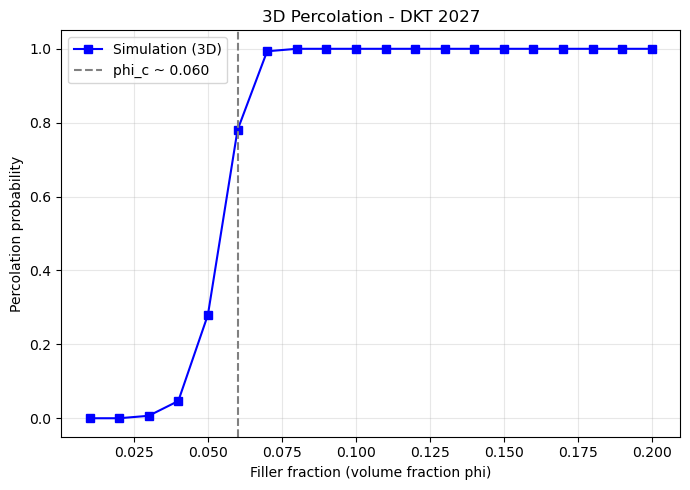

In [10]:
import numpy as np
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt

def single_trial_3d(N, r, L=1.0, k=2.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pts = rng.random((N, 3)) * L          # 3D: her parcacik (x, y, z)
    tree = cKDTree(pts)
    pairs = tree.query_pairs(r=k * 2.0 * r)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(pairs)
    left  = set(np.where(pts[:, 0] <= r)[0])       # x ekseninde sol yuz
    right = set(np.where(pts[:, 0] >= L - r)[0])   # x ekseninde sag yuz
    if not left or not right:
        return False
    for comp in nx.connected_components(G):
        if comp & left and comp & right:
            return True
    return False

def percolation_probability_3d(phi, r, L=1.0, k=2.0, trials=150, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = int(round(phi * L**3 / ((4.0/3.0) * np.pi * r**3)))   # volume fraction -> N
    if N < 1:
        return 0.0
    return sum(single_trial_3d(N, r, L, k, rng) for _ in range(trials)) / trials

rng = np.random.default_rng(42)
r, k, trials = 0.04, 2.0, 150
phi_values = np.linspace(0.01, 0.20, 20)
probs = np.array([percolation_probability_3d(phi, r, k=k, trials=trials, rng=rng)
                  for phi in phi_values])

idx = np.argmax(probs >= 0.5)
phi_c = phi_values[idx] if probs[idx] >= 0.5 else float("nan")
print(f"Estimated 3D percolation threshold phi_c ~ {phi_c:.3f}")

plt.figure(figsize=(7, 5))
plt.plot(phi_values, probs, "s-", color="blue", label="Simulation (3D)")
if not np.isnan(phi_c):
    plt.axvline(phi_c, ls="--", color="gray", label=f"phi_c ~ {phi_c:.3f}")
plt.xlabel("Filler fraction (volume fraction phi)")
plt.ylabel("Percolation probability")
plt.title("3D Percolation - DKT 2027")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

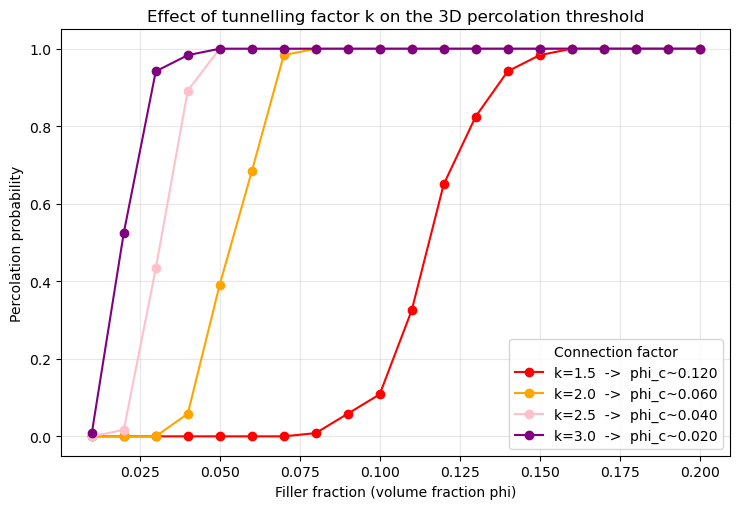

In [12]:
import numpy as np
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt

def single_trial_3d(N, r, L=1.0, k=2.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    pts = rng.random((N, 3)) * L
    tree = cKDTree(pts)
    pairs = tree.query_pairs(r=k * 2.0 * r)
    G = nx.Graph()
    G.add_nodes_from(range(N))
    G.add_edges_from(pairs)
    left  = set(np.where(pts[:, 0] <= r)[0])
    right = set(np.where(pts[:, 0] >= L - r)[0])
    if not left or not right:
        return False
    for comp in nx.connected_components(G):
        if comp & left and comp & right:
            return True
    return False

def percolation_probability_3d(phi, r, L=1.0, k=2.0, trials=120, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = int(round(phi * L**3 / ((4.0/3.0) * np.pi * r**3)))
    if N < 1:
        return 0.0
    return sum(single_trial_3d(N, r, L, k, rng) for _ in range(trials)) / trials

r, trials = 0.04, 120
phi_values = np.linspace(0.01, 0.20, 20)
k_values = [1.5, 2.0, 2.5, 3.0]
colors = ["red", "orange", "pink", "purple"]

plt.figure(figsize=(7.5, 5.2))
for k, col in zip(k_values, colors):
    rng = np.random.default_rng(42)     # her egri icin ayni tohum -> adil karsilastirma
    probs = np.array([percolation_probability_3d(p, r, k=k, trials=trials, rng=rng)
                      for p in phi_values])
    idx = np.argmax(probs >= 0.5)
    phi_c = phi_values[idx] if probs[idx] >= 0.5 else float("nan")
    plt.plot(phi_values, probs, "o-", color=col, label=f"k={k}  ->  phi_c~{phi_c:.3f}")

plt.xlabel("Filler fraction (volume fraction phi)")
plt.ylabel("Percolation probability")
plt.title("Effect of tunnelling factor k on the 3D percolation threshold")
plt.legend(title="Connection factor")
plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

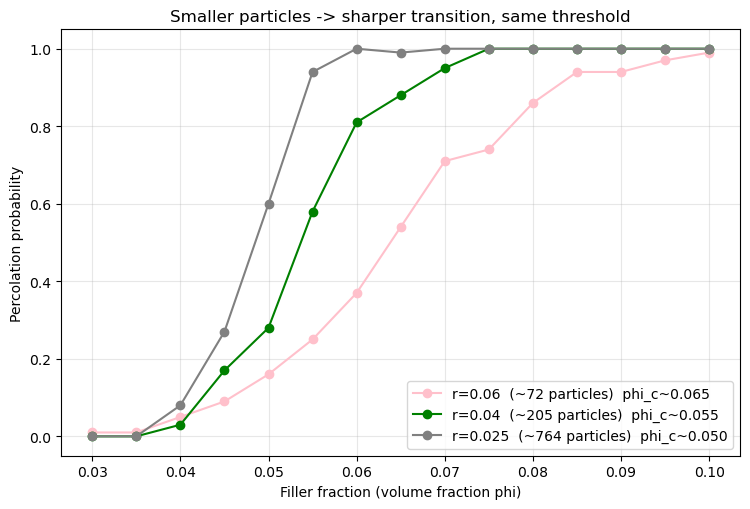

In [14]:
import numpy as np
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt

def sphere_prob(phi, r, k=2.0, L=1.0, trials=100, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    N = int(round(phi * L**3 / ((4/3)*np.pi*r**3)))
    if N < 1:
        return 0.0
    hit = 0
    for _ in range(trials):
        pts = rng.random((N, 3)) * L
        tree = cKDTree(pts)
        pairs = tree.query_pairs(r=k * 2.0 * r)
        G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(pairs)
        left = set(np.where(pts[:, 0] <= r)[0])
        right = set(np.where(pts[:, 0] >= L - r)[0])
        ok = False
        if left and right:
            for comp in nx.connected_components(G):
                if comp & left and comp & right:
                    ok = True; break
        hit += ok
    return hit / trials

phi_values = np.linspace(0.03, 0.10, 15)
r_values = [0.06, 0.04, 0.025]
colors = ["pink", "green", "grey"]

plt.figure(figsize=(7.6, 5.2))
for r, col in zip(r_values, colors):
    rng = np.random.default_rng(42)
    probs = np.array([sphere_prob(p, r, trials=100, rng=rng) for p in phi_values])
    i = np.argmax(probs >= 0.5)
    pc = phi_values[i] if probs[i] >= 0.5 else float("nan")
    Nc = int(round(pc / ((4/3)*np.pi*r**3)))
    plt.plot(phi_values, probs, "o-", color=col,
             label=f"r={r}  (~{Nc} particles)  phi_c~{pc:.3f}")

plt.xlabel("Filler fraction (volume fraction phi)")
plt.ylabel("Percolation probability")
plt.title("Smaller particles -> sharper transition, same threshold")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.show()

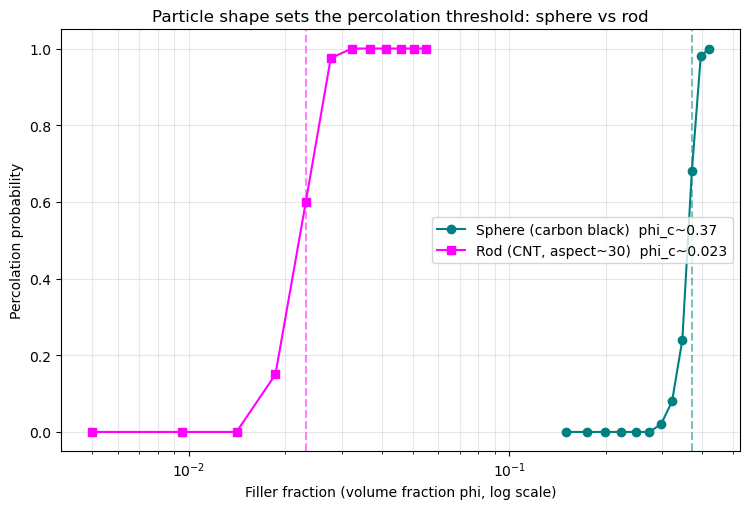

In [19]:
import numpy as np
from scipy.spatial import cKDTree
import networkx as nx
import matplotlib.pyplot as plt

def seg_seg_dist(P1, Q1, P2, Q2):
    # iki cubuk (segment) arasindaki en kisa mesafe - vektörize
    d1 = Q1-P1; d2 = Q2-P2; r = P1-P2
    a = np.einsum('ij,ij->i', d1, d1); e = np.einsum('ij,ij->i', d2, d2)
    f = np.einsum('ij,ij->i', d2, r); c = np.einsum('ij,ij->i', d1, r)
    b = np.einsum('ij,ij->i', d1, d2)
    denom = a*e - b*b
    s = np.where(denom > 1e-12, (b*f - c*e)/np.where(denom > 1e-12, denom, 1), 0.0)
    s = np.clip(s, 0, 1)
    t = (b*s + f)/np.where(e > 1e-12, e, 1)
    t0 = t < 0; t1 = t > 1; t = np.clip(t, 0, 1)
    s = np.where(t0, np.clip(-c/np.where(a > 1e-12, a, 1), 0, 1), s)
    s = np.where(t1, np.clip((b-c)/np.where(a > 1e-12, a, 1), 0, 1), s)
    return np.linalg.norm((P1 + s[:, None]*d1) - (P2 + t[:, None]*d2), axis=1)

def sphere_prob(phi, r, L=1.0, trials=50, rng=None):     # kure = karbon siyahi
    N = int(round(phi*L**3/((4/3)*np.pi*r**3)))
    if N < 1: return 0.0
    hit = 0
    for _ in range(trials):
        pts = rng.random((N, 3))*L
        tree = cKDTree(pts); pairs = tree.query_pairs(r=2.0*r)
        G = nx.Graph(); G.add_nodes_from(range(N)); G.add_edges_from(pairs)
        left = set(np.where(pts[:, 0] <= r)[0]); right = set(np.where(pts[:, 0] >= L-r)[0])
        ok = False
        if left and right:
            for comp in nx.connected_components(G):
                if comp & left and comp & right: ok = True; break
        hit += ok
    return hit/trials

def rod_prob(phi, length, r_rod, L=1.0, trials=40, rng=None):   # cubuk = CNT
    vol = np.pi*r_rod**2*length; N = int(round(phi*L**3/vol))
    if N < 1: return 0.0
    contact = 2.0*r_rod; hit = 0
    for _ in range(trials):
        centers = rng.random((N, 3))*L
        v = rng.normal(size=(N, 3)); v /= np.linalg.norm(v, axis=1, keepdims=True)
        h = 0.5*length; A0 = centers - h*v; A1 = centers + h*v
        tree = cKDTree(centers)
        pr = np.array(list(tree.query_pairs(r=length + contact)), dtype=int)
        G = nx.Graph(); G.add_nodes_from(range(N))
        if len(pr):
            i, j = pr[:, 0], pr[:, 1]
            d = seg_seg_dist(A0[i], A1[i], A0[j], A1[j])
            G.add_edges_from(map(tuple, pr[d <= contact]))
        xmin = np.minimum(A0[:, 0], A1[:, 0]); xmax = np.maximum(A0[:, 0], A1[:, 0])
        left = set(np.where(xmin <= 0.0)[0]); right = set(np.where(xmax >= L)[0])
        ok = False
        if left and right:
            for comp in nx.connected_components(G):
                if comp & left and comp & right: ok = True; break
        hit += ok
    return hit/trials

def threshold(phi, p):
    i = np.argmax(p >= 0.5)
    return phi[i] if p[i] >= 0.5 else float("nan")

phi_sph = np.linspace(0.15, 0.42, 12)
rng = np.random.default_rng(42)
p_sph = np.array([sphere_prob(p, 0.03, trials=50, rng=rng) for p in phi_sph])

phi_rod = np.linspace(0.005, 0.055, 12)
rng = np.random.default_rng(42)
p_rod = np.array([rod_prob(p, 0.30, 0.005, trials=40, rng=rng) for p in phi_rod])

c_sph = threshold(phi_sph, p_sph); c_rod = threshold(phi_rod, p_rod)

plt.figure(figsize=(7.6, 5.2))
plt.plot(phi_sph, p_sph, "o-", color="teal", label=f"Sphere (carbon black)  phi_c~{c_sph:.2f}")
plt.plot(phi_rod, p_rod, "s-", color="magenta", label=f"Rod (CNT, aspect~30)  phi_c~{c_rod:.3f}")
plt.axvline(c_sph, ls="--", color="teal", alpha=0.5)
plt.axvline(c_rod, ls="--", color="magenta", alpha=0.5)
plt.xscale("log")
plt.xlabel("Filler fraction (volume fraction phi, log scale)")
plt.ylabel("Percolation probability")
plt.title("Particle shape sets the percolation threshold: sphere vs rod")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout()
plt.show()